In [1]:
from torchvision import transforms
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
from sklearn.metrics import (accuracy_score, confusion_matrix, f1_score, precision_score, 
                             recall_score, classification_report, ConfusionMatrixDisplay)
from matplotlib import pyplot as plt
import numpy as np
import random

In [2]:
%run "../04_dataset_transforms/dataset.ipynb"

Train: 3094
Validation: 774
{'ambulance': 0, 'autobus': 1, 'kamyun': 2, 'minibus': 3, 'savari': 4, 'taxi': 5, 'vanet': 6}
Train dataset size: 3094
Validation dataset size: 774
Image type: <class 'PIL.Image.Image'>
Label: 0
Image size: (207, 276)
Label type: <class 'int'>
Original size: (207, 276)
Resized size: (224, 224)
Type: <class 'torch.Tensor'>
Shape: torch.Size([3, 224, 224])
Min: tensor(0.0118)
Max: tensor(1.)
Image type: <class 'torch.Tensor'>
Image shape: torch.Size([3, 224, 224])
Label: 0
Label type: <class 'int'>


In [3]:
# %run "../05_dataloader/dataloader.ipynb"

In [4]:
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

torch.use_deterministic_algorithms(True)

print("Seed:", seed)

Seed: 42


In [5]:
train_transform_aug = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# 10.1 — new dataset

In [6]:
train_dataset_aug = TrafficVehicleDataset(
    train_df,
    class_to_idx,
    transform=train_transform_aug
)
val_dataset_aug = TrafficVehicleDataset(
    val_df,
    class_to_idx,
    transform=val_transform
)

# 10.2 — new dataLoader

In [7]:
batch_size = 32
train_loader_aug = DataLoader(
    train_dataset_aug,
    batch_size=batch_size,
    shuffle=True
)
val_loader_aug = DataLoader(
    val_dataset_aug,
    batch_size=batch_size,
    shuffle=False
)

In [8]:
images , labels = next(iter(train_loader_aug))
print('images shape:',images.shape)
print('labels shape:',labels.shape)

images shape: torch.Size([32, 3, 224, 224])
labels shape: torch.Size([32])


# 10.3 — Baseline CNN

In [9]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 56 * 56, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# 10.4 — model, loss, optimizer, decive

In [10]:
model_aug = BaselineCNN(num_classes=7)
print(model_aug)
print('='*80)

criterion_aug = nn.CrossEntropyLoss()
print("Loss:", criterion_aug)
print('='*80)

optimizer_aug = torch.optim.Adam(
    model_aug.parameters(),
    lr=0.001
)
print("Optimizer:\n", optimizer_aug)
print('='*80)

device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)
print('Device:',device)
model_aug = model_aug.to(device)
print("Model device:", next(model_aug.parameters()).device) 

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=200704, out_features=7, bias=True)
  )
)
Loss: CrossEntropyLoss()
Optimizer:
 Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
Device: cpu
Model device: cpu


# 10.5 — Training loop 

In [11]:
num_epochs = 10
train_losses_aug = []
val_losses_aug = []
val_accuracies_aug = []

best_val_accuracy_aug = 0.0
best_epoch_aug = 0

for epoch in range(num_epochs):

    # Training
    model_aug.train()
    train_running_loss = 0.0
    for images, labels in train_loader_aug:

        images = images.to(device)
        labels = labels.to(device)

        optimizer_aug.zero_grad()
        outputs = model_aug(images)

        loss = criterion_aug(outputs, labels)
        loss.backward()

        optimizer_aug.step()
        train_running_loss += loss.item()

    train_loss = train_running_loss / len(train_loader_aug)


    # Validation
    model_aug.eval()
    val_running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader_aug:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model_aug(images)
            loss = criterion_aug(outputs, labels)

            val_running_loss += loss.item()
            predictions = outputs.argmax(dim=1)

            total += labels.size(0)
            correct += (predictions == labels).sum().item()

    val_loss = val_running_loss / len(val_loader_aug)
    val_accuracy = correct / total

    # save results
    train_losses_aug.append(train_loss)
    val_losses_aug.append(val_loss)
    val_accuracies_aug.append(val_accuracy)


    # save best model
    if val_accuracy > best_val_accuracy_aug:

        best_val_accuracy_aug = val_accuracy
        best_epoch_aug = epoch + 1

        torch.save(
            model_aug.state_dict(),
            "best_augmentation_cnn.pth"
        )
        print("  --> Best augmentation model saved!")

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Accuracy: {val_accuracy:.4f}"
    )

print()
print("Best Epoch:", best_epoch_aug)
print("Best Validation Accuracy:", best_val_accuracy_aug)

  --> Best augmentation model saved!
Epoch [1/10] Train Loss: 2.3917 Val Loss: 1.5688 Val Accuracy: 0.4018
  --> Best augmentation model saved!
Epoch [2/10] Train Loss: 1.3361 Val Loss: 1.3883 Val Accuracy: 0.4755
  --> Best augmentation model saved!
Epoch [3/10] Train Loss: 1.1631 Val Loss: 1.3562 Val Accuracy: 0.4974
  --> Best augmentation model saved!
Epoch [4/10] Train Loss: 1.0355 Val Loss: 1.2504 Val Accuracy: 0.5491
  --> Best augmentation model saved!
Epoch [5/10] Train Loss: 0.9840 Val Loss: 1.2045 Val Accuracy: 0.5672
  --> Best augmentation model saved!
Epoch [6/10] Train Loss: 0.9210 Val Loss: 1.1677 Val Accuracy: 0.6021
  --> Best augmentation model saved!
Epoch [7/10] Train Loss: 0.8538 Val Loss: 1.0801 Val Accuracy: 0.6227
Epoch [8/10] Train Loss: 0.7703 Val Loss: 1.1235 Val Accuracy: 0.6163
  --> Best augmentation model saved!
Epoch [9/10] Train Loss: 0.7273 Val Loss: 1.0370 Val Accuracy: 0.6537
  --> Best augmentation model saved!
Epoch [10/10] Train Loss: 0.6655 Val 

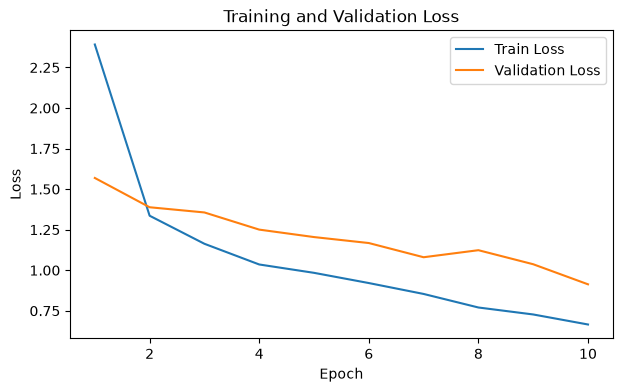

In [13]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(7, 4))

plt.plot(epochs, train_losses_aug, label="Train Loss")
plt.plot(epochs, val_losses_aug, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.show()

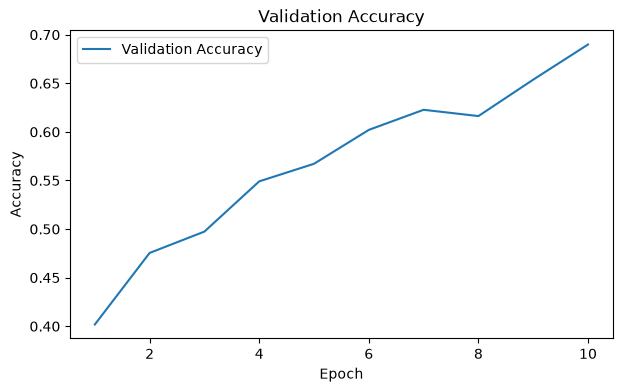

In [14]:
plt.figure(figsize=(7, 4))
plt.plot(epochs, val_accuracies_aug, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy")

plt.legend()
plt.show()

# 10.6 — Baseline evaluation on the validation set

In [15]:
best_model_path = "best_augmentation_cnn.pth"
model_aug.load_state_dict(
    torch.load(
        best_model_path,
        map_location=device
    )
)
model_aug = model_aug.to(device)
model_aug.eval()
print("Best augmentation model loaded successfully.")

Best augmentation model loaded successfully.


In [16]:
all_predictions_aug = []
all_labels_aug = []
model_aug.eval()
with torch.no_grad():
    for images, labels in val_loader_aug:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model_aug(images)
        predictions = outputs.argmax(dim=1)

        all_predictions_aug.extend(predictions.cpu().numpy())
        all_labels_aug.extend(labels.cpu().numpy())
        
print("Number of predictions:", len(all_predictions_aug))
print("Number of labels:", len(all_labels_aug))

Number of predictions: 774
Number of labels: 774


# 10.7 — Precision , Recall , F1 , confusion_matrix

In [17]:
accuracy = accuracy_score(all_labels_aug, all_predictions_aug)
precision = precision_score(all_labels_aug, all_predictions_aug, average="macro")
recall = recall_score(all_labels_aug, all_predictions_aug, average="macro")
f1 = f1_score(all_labels_aug, all_predictions_aug, average="macro")
cm = confusion_matrix(all_labels_aug, all_predictions_aug)

print("Augmentation Results")
print('=' * 40)
print("Validation Accuracy :", accuracy)
print("Validation Precision:", precision)
print("Validation Recall   :", recall)
print("Validation F1 Score :", f1)
print('confusion_matrix    :\n',cm)

Augmentation Results
Validation Accuracy : 0.689922480620155
Validation Precision: 0.7432105269803415
Validation Recall   : 0.6870746442344241
Validation F1 Score : 0.6939625777535705
confusion_matrix    :
 [[ 48   2  18   3   1   0   0]
 [  0  67  19   3   0   4   0]
 [  6   9 158  14   0   2   0]
 [  1   3  23  50   0   1   0]
 [  9   2  24   1  59   2   3]
 [  0   5   1   0   1  90   0]
 [ 12   6  46   6  12   1  62]]


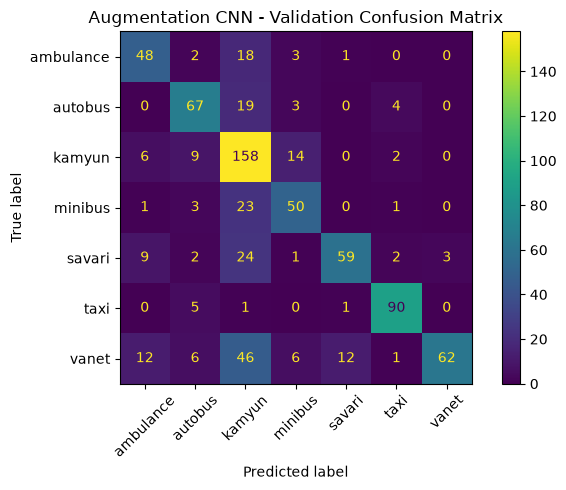

In [18]:
classes = [
    'ambulance',
    'autobus',
    'kamyun',
    'minibus',
    'savari',
    'taxi',
    'vanet'
]
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)
fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(
    ax=ax,
    xticks_rotation=45
)
plt.title("Augmentation CNN - Validation Confusion Matrix")
plt.tight_layout()
plt.show()

# classification_report

In [19]:
report = classification_report(all_labels_aug, all_predictions_aug, target_names=classes)
print(report)

              precision    recall  f1-score   support

   ambulance       0.63      0.67      0.65        72
     autobus       0.71      0.72      0.72        93
      kamyun       0.55      0.84      0.66       189
     minibus       0.65      0.64      0.65        78
      savari       0.81      0.59      0.68       100
        taxi       0.90      0.93      0.91        97
       vanet       0.95      0.43      0.59       145

    accuracy                           0.69       774
   macro avg       0.74      0.69      0.69       774
weighted avg       0.74      0.69      0.69       774

